In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ['GROQ_API_KEY']:
    print("Groq API Key Set!")
else:
    raise ValueError("Groq API Key is not set!!")

Groq API Key Set!


In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-20b")

llm.invoke("Hello!").content    

'Hello! 👋 How can I help you today?'

## **TOOLS**

### Duck Duck Go Search Tool

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

duck_search = DuckDuckGoSearchRun()

duck_search.invoke("Latest Hot News on Iran-US War?")

'This is bad bad bad news for the Mullahs back home in Iran, and I don&t think they have the Luxury to be running over fucking with the Americans in ... The US has carried out more mass airstrikes on Iran on the 11th day of the war. ... US Defence Secretary Pete Hegseth said it was the " most ... Later on Thursday, when asked on “The Five” on Fox News about whether Iranian people have access to basic necessities such as drinking water and ... Daily news & progressive opinion—funded by the people, not the corporations—delivered straight to your inbox. The latest Top News , only from Leading exponents of BlockChain , Bitcoin , Stablecoins , Altcoins and different Accredited Crypto Currency Sources .'

### Arxiv - Find Research Papers

In [6]:
from langchain_community.retrievers import ArxivRetriever

retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
)

retriever.invoke("Transformer in NLP")

[Document(metadata={'Published': '2021-05-14', 'Title': 'A dissemination workshop for introducing young Italian students to NLP', 'Authors': 'Lucio Messina, Lucia Busso, Claudia Roberta Combei, Ludovica Pannitto, Alessio Miaschi, Gabriele Sarti, Malvina Nissim', 'Summary': 'We describe and make available the game-based material developed for a laboratory run at several Italian science festivals to popularize NLP among young students.'}, page_content='A dissemination workshop for introducing young Italian students to NLP\nLucio Messina\nIndependent Researcher\nlucio.messina@autistici.org\nLucia Busso\nAston University\nl.busso@aston.ac.uk\nClaudia Roberta Combei\nUniversity of Bologna\nclaudiaroberta.combei@unibo.it\nLudovica Pannitto\nUniversity of Trento\nludovica.pannitto@unitn.it\nAlessio Miaschi\nUniversity of Pisa\nalessio.miaschi@phd.unipi.it\nGabriele Sarti\nUniversity of Trieste\ngsarti@sissa.it\nMalvina Nissim\nUniversity of Groningen\nm.nissim@rug.nl\nAbstract\nWe describe an

In [7]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

arxiv_query.invoke("Transformers in NLP")

'Published: 2021-09-23\nTitle: Transformers: "The End of History" for NLP?\nAuthors: Anton Chernyavskiy, Dmitry Ilvovsky, Preslav Nakov\nSummary: Recent advances in neural architectures, such as the Transformer, coupled with the emergence of large-scale pre-trained models such as BERT, have revolutionized the field of Natural Language Processing (NLP), pushing the state of the art for a number of NLP tasks. A rich family of variations of these models has been proposed, such as RoBERTa, ALBERT, and XLNet, but fundamentally, they all remain limited in their ability to model certain kinds of information, and they cannot cope with certain information sources, which was easy for pre-existing models. Thus, here we aim to shed light on some important theoretical limitations of pre-trained BERT-style models that are inherent in the general Transformer architecture. First, we demonstrate in practice on two general types of tasks -- segmentation and segment labeling -- and on four datasets that 

### Wikipedia Search Tool

In [8]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

wikipedia.invoke("What are AI Agent Frameworks?")

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-making over content creation and do not require continuous oversight.\n\n\n\nPage: Intelligent agent\nSummary: In artificial intelligence, an intelligent agent is an entity that perceives its environment, takes actions autonomously to achieve goals, and may improve its performance through machine learning or by acquiring knowledge. AI textbooks define artificial intelligence as the "study and design of intelligent agents," emphasizing that goal-directed behavior is central to intelligence.\nA specialized subset of intelligent agents, agentic AI (also known as an AI agent or simply agent), expands this concept by proactively pursuing goals, making decisions, and taking actions over extended peri

### Custom Tool

In [9]:
from langchain.tools import tool

@tool
def personal_tool(name:str):

    """Use this tool to get personal information about Alice, Bob & Charlie!"""

    info = {
        "Alice" : "Alice is Software Developer with 5 yrs experience in AI",
        "Bob" : "Bob is a data scientist who loves working with large datasets",
        "Charlie" : "Charlie is Product Manager with background in tech startups"
    }

    return info.get(name,"No information about this person!")

In [10]:
personal_tool.invoke("Alice")

'Alice is Software Developer with 5 yrs experience in AI'

In [11]:
personal_tool.invoke("Harsh")

'No information about this person!'

## **TOOL BINDING**

In [12]:
tools = [duck_search, arxiv_query, wikipedia, personal_tool]

llm_with_tools = llm.bind_tools(tools)

In [13]:
response = llm_with_tools.invoke("Latest News on AI")

response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'Latest news on AI'},
  'id': 'fc_839e0882-3242-4179-aa59-5192b396cf39',
  'type': 'tool_call'}]

In [14]:
response2 = llm_with_tools.invoke("I want to know personal information about Alice?")

response2.tool_calls

[{'name': 'personal_tool',
  'args': {'name': 'Alice'},
  'id': 'fc_8636ae73-e014-457f-9b8a-786c48162cd9',
  'type': 'tool_call'}]

## **LangGraph Creation**

## Schema

In [15]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages : List

## Node Functions

In [16]:
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state:graph_schema)->graph_schema:

    messages = state['messages']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","You are a helpful assistant that can you tools & answer questions!"),
            ("human","{input}")
        ]
    )

    chain = prompt | llm_with_tools

    response = chain.invoke({"input":messages})

    state['messages'] = messages + [response]

    return state

In [17]:
from langchain_core.messages import ToolMessage
# from langgraph.prebuilt import ToolNode

#Custom ToolNode
def tool_node(state:graph_schema)->graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]
        
        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))

    state['messages'] = messages + tool_results

## Create Conditional Edge

In [18]:
def if_tool_call(state : graph_schema)-> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"


## Create State Graph

In [19]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("LLM_Node", llm_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "LLM_Node")
graph.add_conditional_edges("LLM_Node", if_tool_call,{"tool_node":"tool_node","end":END})
graph.add_edge("tool_node", "LLM_Node")
graph.add_edge("LLM_Node", END)

react_graph = graph.compile()

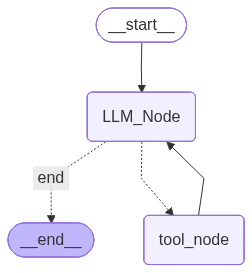

In [20]:
from IPython.display import Image,display

Image(react_graph.get_graph().draw_mermaid_png())

## Graph Invocation

In [21]:
from langchain_core.messages import HumanMessage
react_graph.invoke({"messages" : [HumanMessage(content="What is the latest news on US Iran War?")]})

{'messages': [HumanMessage(content='What is the latest news on US Iran War?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks about latest news on US Iran War. Likely no such war. Need to check current events. Use duckduckgo_search.', 'tool_calls': [{'id': 'fc_aaeaf06d-8a41-451f-98a8-5e256a3ea364', 'function': {'arguments': '{"query":"latest news US Iran war"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 347, 'total_tokens': 406, 'completion_time': 0.061116919, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.018344981, 'prompt_tokens_details': None, 'queue_time': 0.049220192, 'total_time': 0.0794619}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9a9d-bd22-7f

In [22]:
from langchain_core.messages import HumanMessage
for chunk in react_graph.stream(
    {'messages': [HumanMessage(content="Latest News on AI")]},
):
    print(chunk)

{'LLM_Node': {'messages': [HumanMessage(content='Latest News on AI', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Latest News on AI". We need to provide latest news. We should use DuckDuckGo search to find recent news. Use search query: "latest news on AI".', 'tool_calls': [{'id': 'fc_ad97194d-5b9f-4590-9a14-ebf9be7aad4f', 'function': {'arguments': '{"query":"latest news on AI"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 342, 'total_tokens': 411, 'completion_time': 0.074731685, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.01315424, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.04883629, 'total_time': 0.087885925}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_prov

KeyboardInterrupt: 